# Market-consensus Kelly staking experiment

## A model-free benchmark against the pooled L2 strategy

**Research question.** Can a no-vig probability derived only from average
pre-closing over/under odds identify value at Bet365, Pinnacle, Betfair
Exchange, the pre-closing market maximum, or the closing market maximum—and
does fractional Kelly convert any such edge into stable bankroll growth?

This experiment does **not** fit the pooled logistic model. Kelly is a staking
rule, not a forecasting model: the forecasting signal here is the market
consensus probability. The analysis is deliberately separate from notebook 01.


In [13]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from football_edge.backtest import (
    build_research_dataset,
    probability_performance,
    summarize_bets,
)
from football_edge.config import (
    CONSENSUS_KELLY_MINIMUM_EXPECTED_VALUE,
    RAW_DATA_DIR,
)
from football_edge.data import discover_datasets
from football_edge.staking import (
    DEFAULT_KELLY_CONFIGURATIONS,
    build_consensus_candidates,
    cluster_bootstrap_roi,
    simulate_kelly_bankroll,
    summarize_kelly_paths,
)

pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")

# Experiment parameters. Override this value here for a clearly
# labelled sensitivity run without changing the pooled-model threshold.
KELLY_EV_THRESHOLD = CONSENSUS_KELLY_MINIMUM_EXPECTED_VALUE  # 0.005 = 0.5%
INITIAL_BANKROLL = 100.0
PRIMARY_STRATEGY = "25% Kelly, 1% cap"


SOURCE_ORDER = [
    "bet365",
    "pinnacle",
    "betfair_exchange",
    "best_preclosing",
    "best_closing",
]
SOURCE_LABELS = {
    "bet365": "Bet365",
    "pinnacle": "Pinnacle",
    "betfair_exchange": "Betfair Exchange",
    "best_preclosing": "Market maximum",
    "best_closing": "Closing maximum*",
}
SOURCE_COLORS = {
    "bet365": "#2CA02C",
    "pinnacle": "#1F77B4",
    "betfair_exchange": "#FF7F0E",
    "best_preclosing": "#9467BD",
    "best_closing": "#D62728",
}


## 1. Prespecified design

The consensus over probability removes the two-sided market margin:

\[
p_{over}=\frac{1/AvgOver}{1/AvgOver+1/AvgUnder}.
\]

For execution odds \(O\), estimated value is \(p_{over}O-1\). A candidate
is selected when EV is at least the consensus-Kelly experiment's exploratory 0.5% threshold.
The full binary Kelly fraction is

\[
f^*=\max\left(0,\frac{p_{over}O-1}{O-1}\right).
\]

The primary staking rule is **25% Kelly capped at 1% of current bankroll per
bet**. The 10%, 50%, and capped full-Kelly variants are sensitivity analyses,
not parameters selected from the observed results. Bets sharing an exact
timestamp are sized from the same bankroll and settled together.

Important interpretation:

- Bet365, Pinnacle, and Betfair are named-venue proxies.
- `Max>2.5` is an optimistic pre-closing best-price proxy.
- `MaxC>2.5` is a **non-executable closing-price sensitivity** and must not be
  presented as a feasible strategy.
- The market average may contain the tested named venues. Without constituent
  quotes, leave-one-bookmaker-out consensus probabilities cannot be computed.


In [14]:
datasets = discover_datasets(RAW_DATA_DIR)
all_matches = build_research_dataset(datasets)

dataset_summary = pd.DataFrame(
    {
        "Matches": [len(all_matches)],
        "Leagues": [all_matches["league"].nunique()],
        "Seasons": [all_matches["season"].nunique()],
        "First match": [all_matches["date"].min()],
        "Last match": [all_matches["date"].max()],
        "Consensus coverage": [
            all_matches["market_over_probability"].notna().mean()
        ],
    }
)
dataset_summary.assign(
    **{"Consensus coverage (%)": (dataset_summary["Consensus coverage"] * 100).round(2)}
).drop(columns="Consensus coverage")


,Matches,Leagues,Seasons,First match,Last match,Consensus coverage (%)
0,7230,4,5,2021-08-13 19:30:00,2026-05-24 20:00:00,99.99


## 2. Consensus probability quality

Kelly is highly sensitive to probability error, so calibration is checked
before bankroll results. Brier score and log loss are lower-is-better;
calibration intercept and slope should be approximately 0 and 1.
League-season results reveal whether apparently good aggregate calibration
hides instability.


In [15]:
consensus_matches = all_matches.dropna(
    subset=["market_over_probability", "over_2_5"]
).copy()
consensus_matches["forecaster"] = "No-vig average market"

overall_calibration = probability_performance(
    consensus_matches,
    probability_column="market_over_probability",
    group_by=["forecaster"],
)
calibration_by_league_season = probability_performance(
    consensus_matches,
    probability_column="market_over_probability",
    group_by=["league", "season"],
)

headline_calibration = overall_calibration[
    [
        "observations",
        "brier_score",
        "log_loss",
        "calibration_intercept",
        "calibration_slope",
        "mean_probability",
        "event_rate",
    ]
].copy()
headline_calibration[["mean_probability", "event_rate"]] *= 100
headline_calibration = headline_calibration.rename(
    columns={
        "mean_probability": "mean_probability_pct",
        "event_rate": "event_rate_pct",
    }
)
headline_calibration.round(4)


,observations,brier_score,log_loss,calibration_intercept,calibration_slope,mean_probability_pct,event_rate_pct
0,7229,0.2387,0.67,-0.0008,1.1165,52.7924,53.064


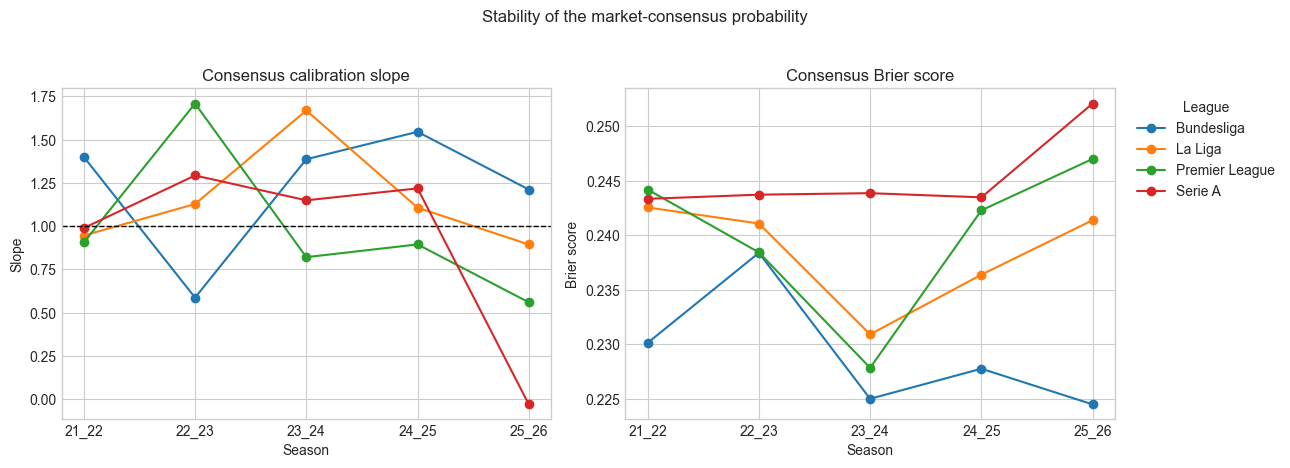

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for league, group in calibration_by_league_season.groupby("league"):
    axes[0].plot(group["season"], group["calibration_slope"], marker="o", label=league)
    axes[1].plot(group["season"], group["brier_score"], marker="o", label=league)

axes[0].axhline(1, color="black", linestyle="--", linewidth=1)
axes[0].set(title="Consensus calibration slope", ylabel="Slope", xlabel="Season")
axes[1].set(title="Consensus Brier score", ylabel="Brier score", xlabel="Season")
axes[1].legend(title="League", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Stability of the market-consensus probability", y=1.03)
fig.tight_layout()
plt.show()


## 3. Candidate construction and execution coverage

All five execution scenarios use the same consensus probability and 0.5% EV
rule. Candidate sets still differ because quote coverage and offered prices
differ. This is economically appropriate, but comparisons must show their
sample sizes.


In [17]:
bets = build_consensus_candidates(
    all_matches,
    minimum_expected_value=KELLY_EV_THRESHOLD,
)
print(f"Consensus-Kelly EV threshold: {KELLY_EV_THRESHOLD:.1%}")

selection_summary = (
    bets.groupby(["execution_source", "is_executable_proxy"], sort=True)
    .agg(
        bets=("profit", "size"),
        leagues=("league", "nunique"),
        seasons=("season", "nunique"),
        mean_probability=("signal_probability", "mean"),
        mean_odds=("bet_odds", "mean"),
        mean_estimated_ev=("expected_value", "mean"),
    )
    .reset_index()
)


Consensus-Kelly EV threshold: 0.5%


## 4. Does the signal have stable flat-stake value?

Flat-stake ROI is evaluated before Kelly so signal quality is not confused
with path-dependent sizing. The bootstrap resamples whole calendar dates,
preserving some same-day dependence across leagues. Its intervals describe
sampling uncertainty only; they do not correct quote-timing or executability
bias.

At least 30 independent date clusters are required before bootstrap intervals
are reported. Below that level, intervals are suppressed rather than displaying
spuriously precise results from one or a handful of repeated observations.


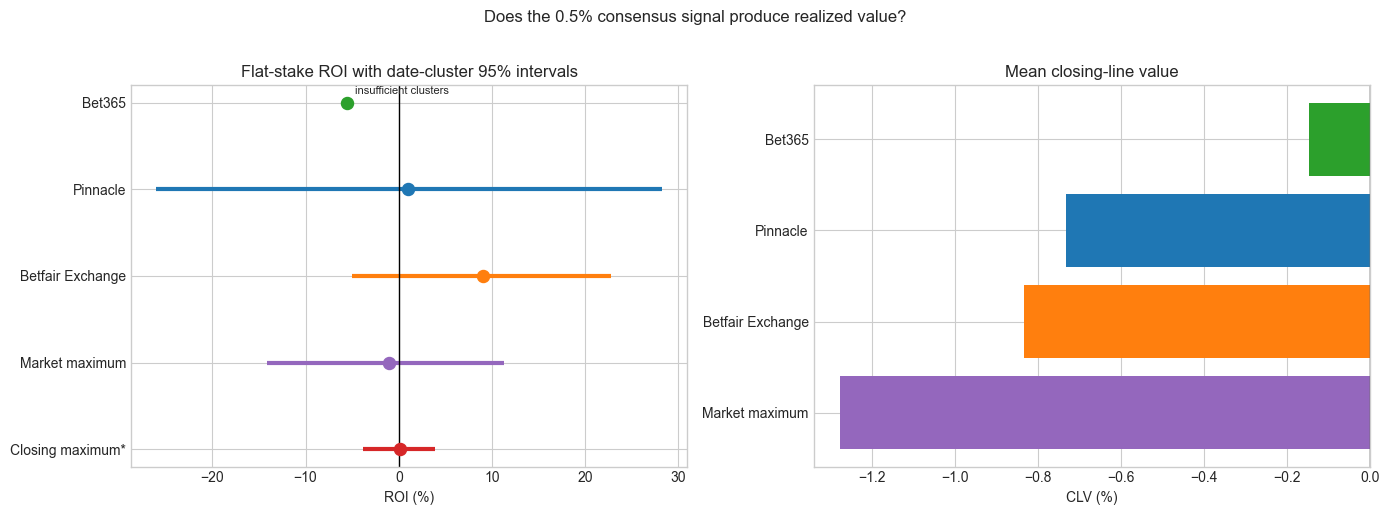

In [18]:
flat_summary = summarize_bets(bets, ["execution_source"])
bootstrap_summary = cluster_bootstrap_roi(
    bets,
    n_bootstrap=5000,
    random_seed=42,
)
headline_performance = flat_summary.merge(
    bootstrap_summary[
        [
            "execution_source",
            "date_clusters",
            "sufficient_clusters_for_inference",
            "roi_95_low_pct",
            "roi_95_high_pct",
        ]
    ],
    on="execution_source",
    suffixes=("_normal", ""),
)
plot_data = (
    headline_performance.set_index("execution_source")
    .reindex(SOURCE_ORDER)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for position, row in plot_data.iterrows():
    color = SOURCE_COLORS[row["execution_source"]]
    axes[0].scatter(row["roi_pct"], position, color=color, s=75, zorder=3)
    if pd.notna(row["roi_95_low_pct"]):
        axes[0].hlines(
            position,
            row["roi_95_low_pct"],
            row["roi_95_high_pct"],
            color=color,
            linewidth=3,
        )
    else:
        axes[0].annotate(
            "insufficient clusters",
            (row["roi_pct"], position),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=8,
        )

axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_yticks(
    range(len(plot_data)),
    [SOURCE_LABELS[source] for source in plot_data["execution_source"]],
)
axes[0].invert_yaxis()
axes[0].set(
    title="Flat-stake ROI with date-cluster 95% intervals",
    xlabel="ROI (%)",
)

clv_data = plot_data.loc[
    plot_data["execution_source"].ne("best_closing")
]
axes[1].barh(
    [SOURCE_LABELS[source] for source in clv_data["execution_source"]],
    clv_data["mean_clv_pct"],
    color=[SOURCE_COLORS[source] for source in clv_data["execution_source"]],
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].invert_yaxis()
axes[1].set(title="Mean closing-line value", xlabel="CLV (%)")

fig.suptitle("Does the 0.5% consensus signal produce realized value?", y=1.02)
fig.tight_layout()
plt.show()


### Cumulative flat-stake profit

These paths show when profit and drawdown occurred. Each panel has its own
y-axis because execution samples differ by orders of magnitude. The closing
maximum remains a non-executable diagnostic.


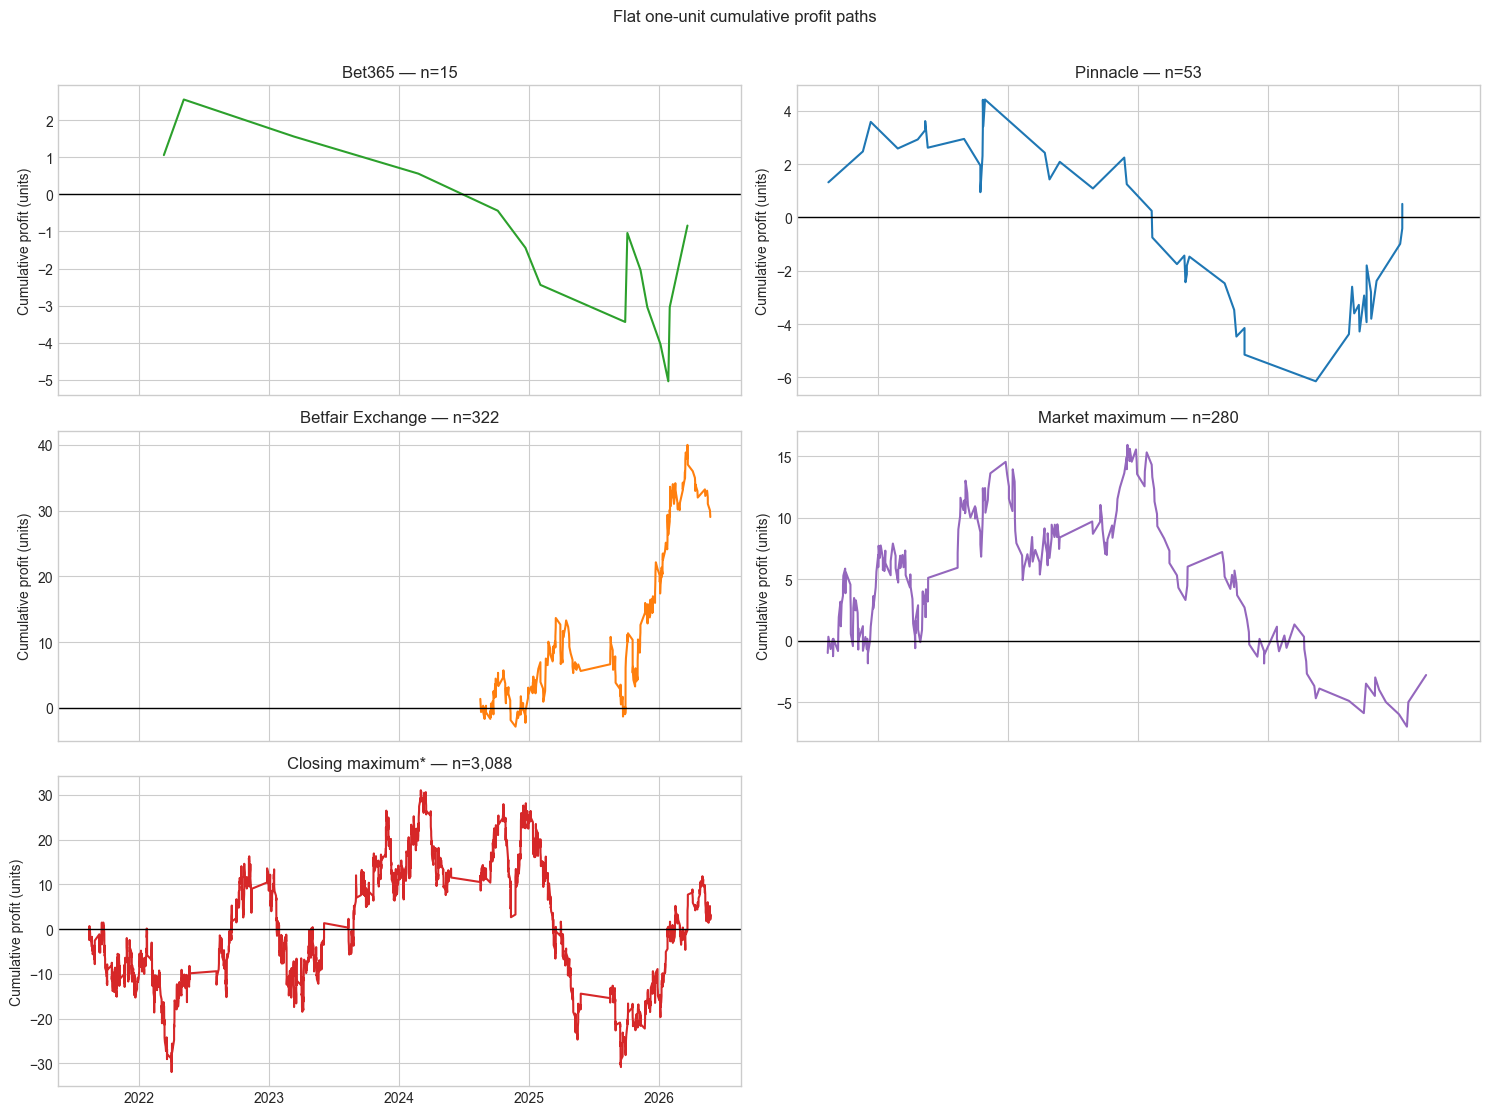

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
axes = axes.ravel()
for axis, source in zip(axes, SOURCE_ORDER):
    source_bets = (
        bets.loc[bets["execution_source"].eq(source)]
        .sort_values("date", kind="stable")
        .copy()
    )
    source_bets["cumulative_profit"] = source_bets["profit"].cumsum()
    axis.plot(
        source_bets["date"],
        source_bets["cumulative_profit"],
        color=SOURCE_COLORS[source],
        linewidth=1.5,
    )
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title(f"{SOURCE_LABELS[source]} — n={len(source_bets):,}")
    axis.set_ylabel("Cumulative profit (units)")

axes[-1].axis("off")
fig.suptitle("Flat one-unit cumulative profit paths", y=1.01)
fig.tight_layout()
plt.show()


In [20]:
flat_stability = summarize_bets(
    bets, ["execution_source", "league", "season"]
)
season_stability = summarize_bets(
    bets, ["execution_source", "season"]
)


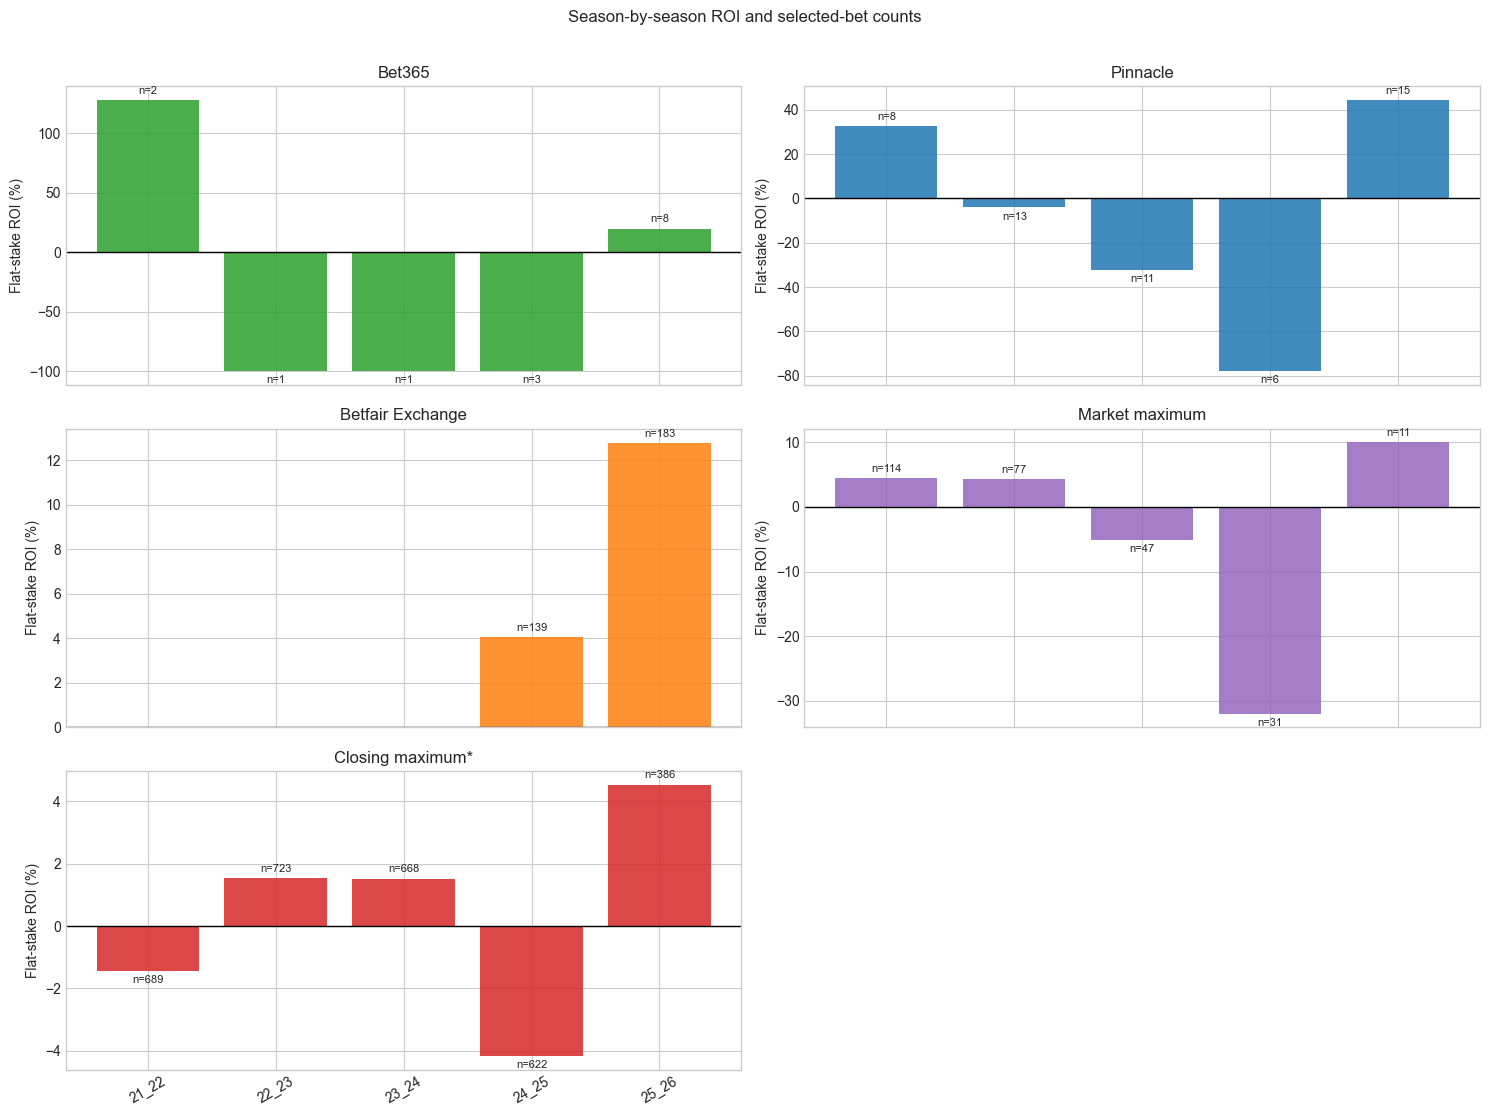

In [21]:
season_order = sorted(all_matches["season"].unique())
fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
axes = axes.ravel()

for axis, source in zip(axes, SOURCE_ORDER):
    subset = (
        season_stability.loc[
            season_stability["execution_source"].eq(source)
        ]
        .set_index("season")
        .reindex(season_order)
        .reset_index()
    )
    bars = axis.bar(
        subset["season"],
        subset["roi_pct"],
        color=SOURCE_COLORS[source],
        alpha=0.85,
    )
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title(SOURCE_LABELS[source])
    axis.set_ylabel("Flat-stake ROI (%)")
    labels = [
        f"n={int(value)}" if pd.notna(value) else ""
        for value in subset["bets"]
    ]
    axis.bar_label(bars, labels=labels, padding=3, fontsize=8)
    axis.tick_params(axis="x", rotation=30)

axes[-1].axis("off")
fig.suptitle("Season-by-season ROI and selected-bet counts", y=1.01)
fig.tight_layout()
plt.show()


### Selected-bet sample size by execution strategy

The logarithmic axis is necessary because the closing-maximum sensitivity has
orders of magnitude more selected bets than the executable proxies. Kelly
variants within an execution source use exactly the same selected matches, so
their bet counts are identical; only stake sizes differ.


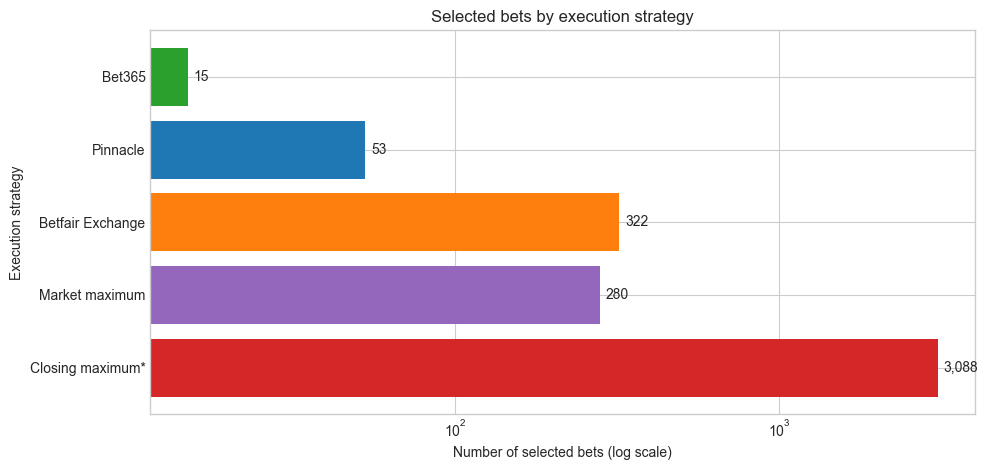

In [22]:
strategy_counts = (
    bets.groupby("execution_source", sort=False)
    .size()
    .reindex(SOURCE_ORDER)
    .rename("bets")
    .reset_index()
)

fig, axis = plt.subplots(figsize=(10, 4.8))
bars = axis.barh(
    [SOURCE_LABELS[source] for source in strategy_counts["execution_source"]],
    strategy_counts["bets"],
    color=[
        SOURCE_COLORS[source]
        for source in strategy_counts["execution_source"]
    ],
)
axis.set_xscale("log")
axis.set(
    title="Selected bets by execution strategy",
    xlabel="Number of selected bets (log scale)",
    ylabel="Execution strategy",
)
axis.bar_label(
    bars,
    labels=strategy_counts["bets"].map(lambda value: f"{value:,}"),
    padding=4,
)
axis.invert_yaxis()
fig.tight_layout()
plt.show()


## 5. Fractional Kelly bankroll paths

Each execution source and Kelly configuration receives an independent initial
bankroll of 100 units. Reported bankroll return is not comparable to the
flat-stake ROI denominator: Kelly changes both stake sizes and capital through
time. Maximum drawdown, turnover, and concentration are therefore essential.


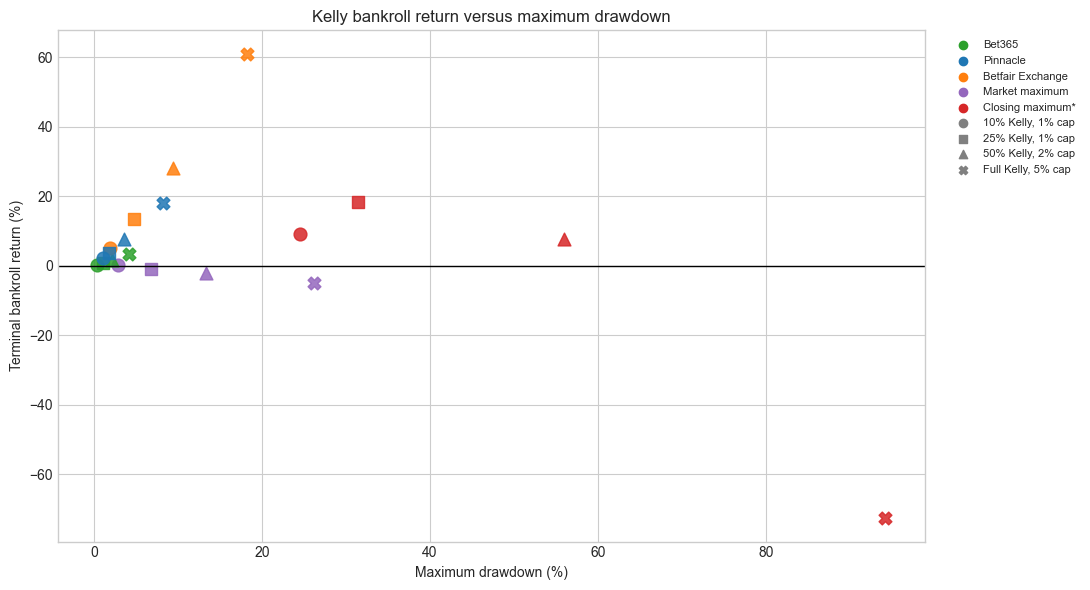

In [23]:
kelly_paths = simulate_kelly_bankroll(
    bets,
    configurations=DEFAULT_KELLY_CONFIGURATIONS,
    initial_bankroll=INITIAL_BANKROLL,
)
kelly_summary = summarize_kelly_paths(
    kelly_paths,
    initial_bankroll=INITIAL_BANKROLL,
)

fig, axis = plt.subplots(figsize=(11, 6))
markers = {
    "10% Kelly, 1% cap": "o",
    "25% Kelly, 1% cap": "s",
    "50% Kelly, 2% cap": "^",
    "Full Kelly, 5% cap": "X",
}
for _, row in kelly_summary.iterrows():
    source = row["execution_source"]
    strategy = row["strategy"]
    axis.scatter(
        row["max_drawdown_pct"],
        row["bankroll_return_pct"],
        color=SOURCE_COLORS[source],
        marker=markers[strategy],
        s=85,
        alpha=0.85,
    )

for source in SOURCE_ORDER:
    axis.scatter([], [], color=SOURCE_COLORS[source], label=SOURCE_LABELS[source])
for strategy, marker in markers.items():
    axis.scatter([], [], color="gray", marker=marker, label=strategy)

axis.axhline(0, color="black", linewidth=1)
axis.set(
    title="Kelly bankroll return versus maximum drawdown",
    xlabel="Maximum drawdown (%)",
    ylabel="Terminal bankroll return (%)",
)
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()


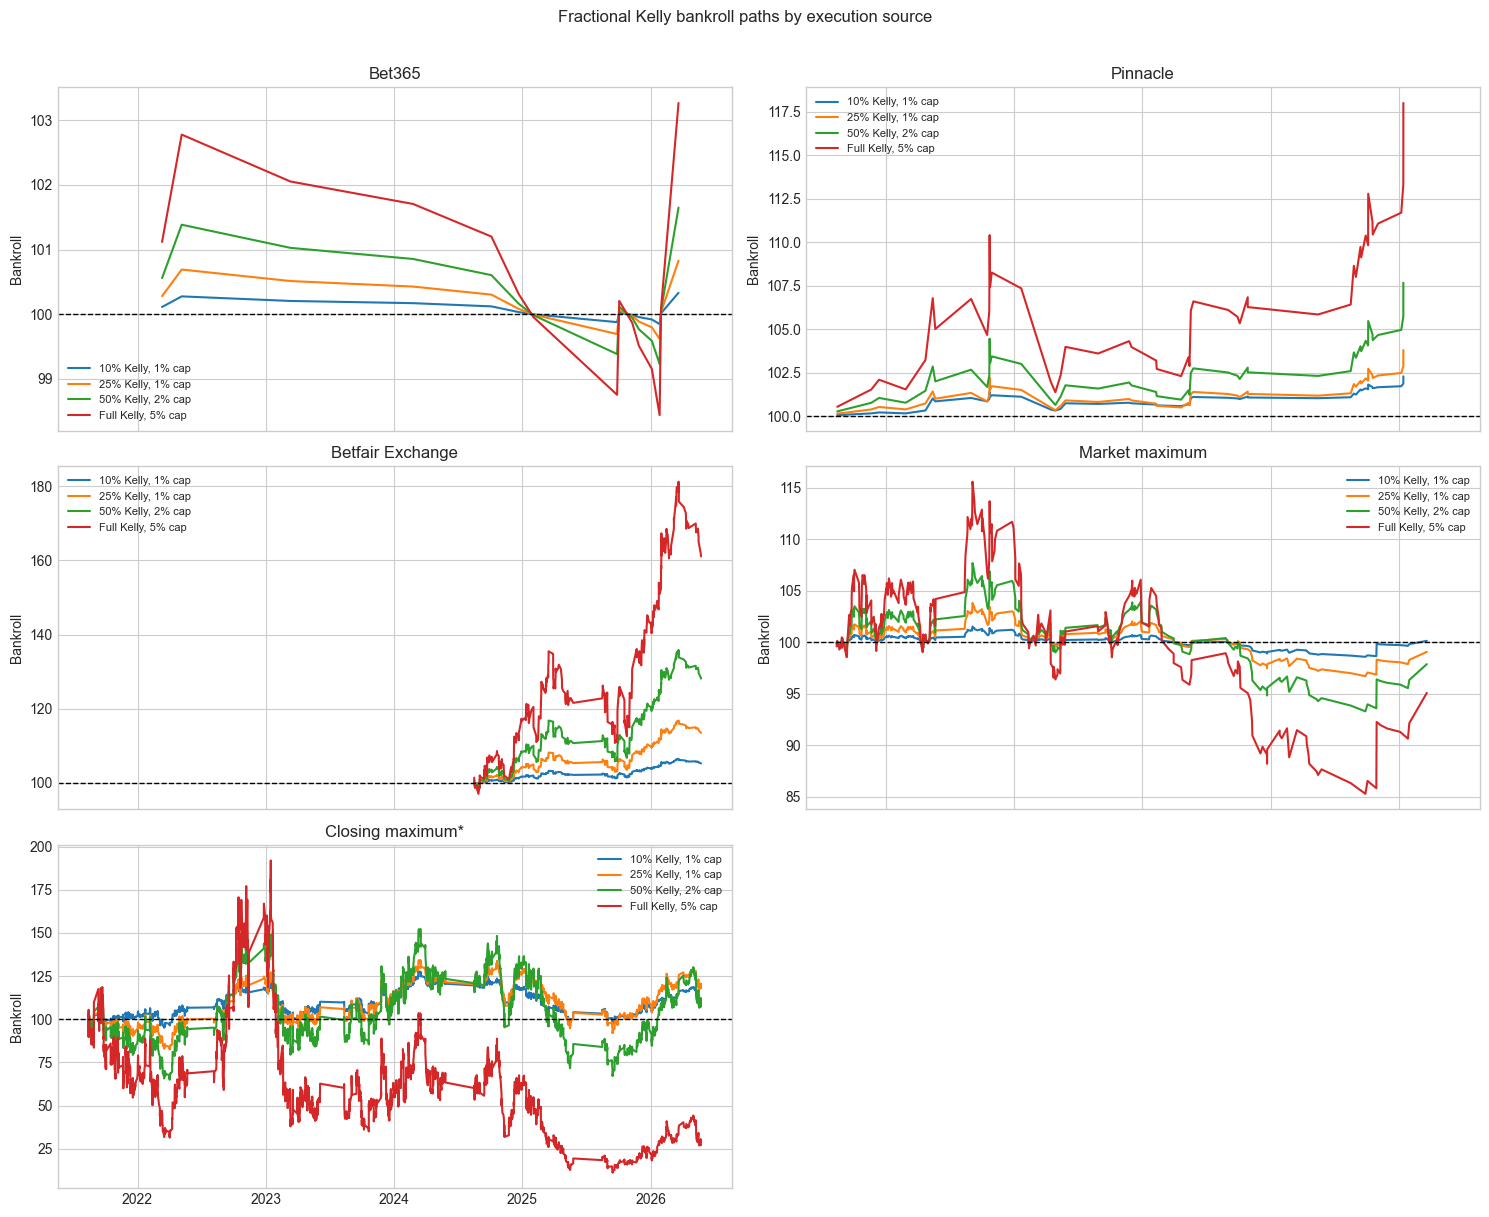

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
axes = axes.ravel()

for axis, source in zip(axes, SOURCE_ORDER):
    source_paths = kelly_paths.loc[
        kelly_paths["execution_source"].eq(source)
    ]
    for strategy, group in source_paths.groupby("strategy"):
        path = (
            group.groupby("date", sort=True)["bankroll_after_batch"]
            .last()
        )
        axis.plot(path.index, path.values, label=strategy)
    axis.axhline(INITIAL_BANKROLL, color="black", linestyle="--", linewidth=1)
    axis.set_title(
        SOURCE_LABELS[source]
    )
    axis.set_ylabel("Bankroll")
    axis.legend(fontsize=8)

axes[-1].axis("off")
fig.suptitle("Fractional Kelly bankroll paths by execution source", y=1.01)
fig.tight_layout()
plt.show()


## 6. Primary-strategy stability and concentration

The next tables isolate the prespecified quarter-Kelly strategy. Return on
stakes by league and season is useful for stability, while stake concentration
shows whether terminal wealth is dominated by a small number of positions.
These decompositions are descriptive because bankroll is shared through time
within each execution source.


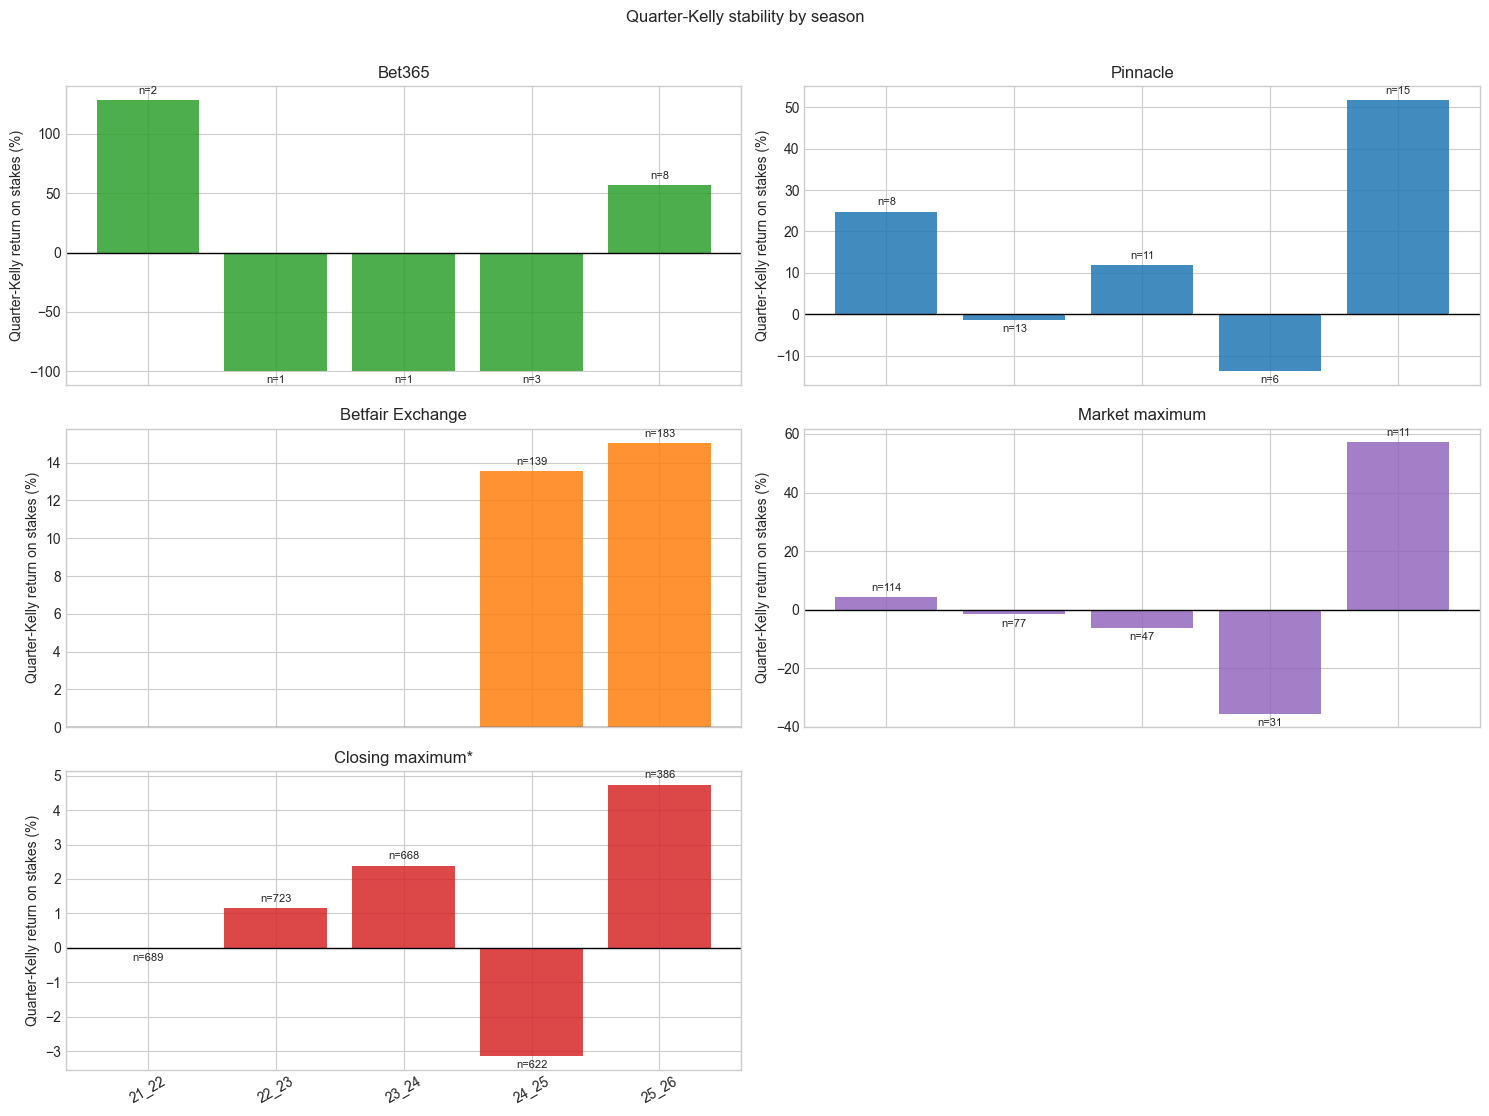

In [25]:
primary_paths = kelly_paths.loc[
    kelly_paths["strategy"].eq(PRIMARY_STRATEGY)
].copy()

primary_season = (
    primary_paths.groupby(["execution_source", "season"], sort=True)
    .agg(
        bets=("pnl", "size"),
        staked=("stake", "sum"),
        pnl=("pnl", "sum"),
    )
    .reset_index()
)
primary_season["return_on_stakes_pct"] = (
    primary_season["pnl"] / primary_season["staked"] * 100
)

fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
axes = axes.ravel()
for axis, source in zip(axes, SOURCE_ORDER):
    subset = (
        primary_season.loc[
            primary_season["execution_source"].eq(source)
        ]
        .set_index("season")
        .reindex(season_order)
        .reset_index()
    )
    bars = axis.bar(
        subset["season"],
        subset["return_on_stakes_pct"],
        color=SOURCE_COLORS[source],
        alpha=0.85,
    )
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title(SOURCE_LABELS[source])
    axis.set_ylabel("Quarter-Kelly return on stakes (%)")
    axis.bar_label(
        bars,
        labels=[
            f"n={int(value)}" if pd.notna(value) else ""
            for value in subset["bets"]
        ],
        padding=3,
        fontsize=8,
    )
    axis.tick_params(axis="x", rotation=30)

axes[-1].axis("off")
fig.suptitle("Quarter-Kelly stability by season", y=1.01)
fig.tight_layout()
plt.show()


## 7. Interpretation checklist

Before concluding that the strategy has value, check:

1. Is consensus calibration reasonably stable across leagues and seasons?
2. Is flat-stake ROI positive across several independent periods, rather than
   driven by one league, season, or execution source?
3. Does the date-cluster bootstrap interval exclude zero?
4. Does quarter Kelly improve growth without unacceptable drawdown?
5. Are results robust at named venues, rather than only `Max` or `MaxC`?
6. Are turnover and the largest-bet share plausible?
7. Do more aggressive Kelly variants mainly increase drawdown? If so, model
   uncertainty is economically important.

Even a positive result remains provisional: average and execution quotes may
not be synchronized, the average may include the tested bookmaker, Betfair
commission is zero, and limits/liquidity are unavailable.


## 8. Conclusions

### Headline result

At the exploratory 0.5% EV threshold, the model-free consensus strategy does
not establish a robust executable edge. Lowering the threshold materially
increases the sample, but the confidence intervals and stability plots remain
more informative than the positive point estimates.

### Profit and loss

Betfair Exchange is the strongest named-source result: 322 bets produce 29.01
flat-stake units and 9.01% ROI. However, the date-cluster 95% interval remains
wide and crosses zero (approximately -5.02% to 22.77%), while mean CLV is
-0.83%. The result is interesting enough for prospective validation, but not
strong enough to claim an edge.

Pinnacle is approximately flat: 53 bets produce 0.51 units and 0.96% ROI, with
a very wide interval (-26.04% to 28.25%) and negative mean CLV (-0.73%).
Bet365 loses 0.84 units across only 15 bets; this is below the minimum number
of date clusters required for bootstrap inference. The pre-closing market
maximum loses 2.79 units over 280 bets (-1.00% ROI) and also has negative CLV.

The closing maximum is non-executable and should not be used as evidence of
profitability. Its 3,088 bets produce only 3.11 units (0.10% ROI), with an
interval spanning roughly -3.80% to 3.93%.

### Stability

Returns are not stable across seasons or leagues. Betfair's aggregate profit is
concentrated in the two seasons for which exchange quotes are available, and
its league-season outcomes contain both material gains and losses. Pinnacle and
Bet365 estimates are dominated by very small subgroup counts. The market
maximum also changes sign repeatedly across seasons. This instability is
inconsistent with a mature, repeatable pricing edge.

### Kelly staking

Quarter Kelly turns the Betfair path into a 13.44% bankroll gain with a 4.79%
maximum drawdown, but this is not independent evidence: it is a path-dependent
transformation of the same uncertain 322-bet result. More aggressive Kelly
fractions increase Betfair's historical terminal wealth, yet should not be
selected retrospectively.

The non-executable closing-maximum experiment demonstrates the downside of
probability error. Quarter Kelly gains 18.24% but experiences a 31.49% maximum
drawdown, while capped full Kelly loses 72.69% and reaches a 94.16% drawdown.
This supports fractional and capped staking only after an edge has been
validated; Kelly cannot create an edge.

### Research conclusion

The 0.5% threshold is useful as an exploratory sensitivity because it supplies
more observations than 1% or 3%. It does not, however, solve the core data
limitations. Quotes are not timestamp-synchronized, the market average may
include the tested bookmaker, Betfair commission is assumed to be zero, and
liquidity and limits are unavailable.

The defensible conclusion is therefore: **no robust executable edge has been
demonstrated**. Betfair is the only result that merits further investigation,
preferably with verified commission, synchronized leave-one-bookmaker-out
consensus probabilities, and prospective paper trading. Flat-stake performance
and CLV should remain the primary evidence; Kelly results are secondary risk
diagnostics.
